**Lab 5: FIR Filtering 2**

The goal of this lab is to study the response of FIR filters to inputs such as complex exponentials and sinusoids. In the experiments of this lab, you will use `np.convolve()` to implement filters and `freqz()` to obtain the filter’s frequency response. As a result, you should learn how to characterize a filter by knowing how it reacts to different frequency components in the input.
This lab also introduces two practical filters: bandpass filters and nulling filters.
Bandpass filters can be used to detect and extract information from complex signals,
e.g., tones in a touch-tone telephone dialer. Nulling filters can be used to remove
sinusoidal interference, e.g., jamming signals in a radar.

In [1]:
import os
import numpy as np
import librosa
import IPython.display as ipd
from scipy import signal
import matplotlib.pyplot as plt

from util import load_audio, plot_signals, plot_spectrogram, plot_mean_spectrogram

1.1. First, let's replicate what we did until now. Copy the functions synthesize and envelope and obtain the synthesis from the last lab.

In [ ]:
#!git clone https://github.com/guillemmarti06/sis1_group103.git 
filepath = "./sis1_group103/audio_la.wav"
ref, fs = load_audio(filepath)

def envelope(x, N):
    x_rect = np.abs(x)
    kernel = np.ones(N) / N
    y = np.convolve(x_rect, kernel, 'same')

    return y, kernel

def synthesize(f0, phi, Ak, t):
    y = 0
    for k in range(1, len(Ak) + 1):
        y += Ak[k-1] * np.cos(2*np.pi*k*f0*t + k*phi - (k-1)*np.pi/2)
    return y

# From previous labs...
weights = [1, 0.4522836, 0.1879079, 0.2577941, 0.3784587, 0.06882009] 
phi = np.pi / 2
f0 = 440
fs = 44100
T = 1 / f0

# Generate the synthesized sinusoidal signal 
t = np.arange(0, len(ref) / fs, 1 / fs)
y = synthesize(f0, phi, weights, t)
y_syn = np.max(np.abs(ref)) * y / np.max(np.abs(y))

env, _ = envelope(ref, 5)
env = env / np.max(env)
syn = y_syn * env   # Now syn is the synthesis obtained from lab 4 after the multiplication 

1.2 Plot both reference and synthesised signal.

In [6]:
f0 = 440
T = 1 / f0
t_start = 0.15                
t_end = t_start + 5 * T
plot_signals([ref, syn], fs, t_start , t_end, name=['input [x] (ref)', 'output [y] (syn from lab4)'], mode= 'lines+markers')

---

**2. Averaging filter**

Now let's analyze the frequency response of the average filter used in the envelope function. The Scipy Python module has a function called *freqz()* for computing the frequency
response of a discrete-time LTI system. The following Python statements show how to
use freqz to compute and plot both the magnitude (absolute value) and the phase of
the frequency response of a four-point averaging system as a function of ω in the range − π ≤ ω ≤ π :

In [112]:
from util import plot_frequency_response
n = 4
b = np.ones((n))/n
ww_full, H_full = signal.freqz(b, whole = True)
ww = np.fft.fftshift(ww_full)
H = np.fft.fftshift(H_full)

ww = np.where(ww > np.pi, ww - 2 * np.pi, ww)
plot_frequency_response(ww, H)


For FIR filters, the second argument of `freqz(-, 1,- )` must always be equal to 1. The frequency vector ww should cover an interval of length 2π for ω , and its spacing must be fine enough to give a smooth curve for H(ejω) . Note: we will always use capital H for the frequency response.

2.1 Use the `freqz` and `plot_frequency_response` functions to plot the frequency response of the averaging filter of your envelope function.



In [114]:
b = y
ww_full, H_full = signal.freqz(b, [1], whole=True) # fulfil the statement

ww = np.fft.fftshift(ww_full)
H = np.fft.fftshift(H_full)

ww = np.where(ww > np.pi, ww - 2 * np.pi, ww)
plot_frequency_response(ww, H)

2.2 Looking at the frequency responses, what are the main differences between your filter and the four-point averaging filter. What happens when the value N is increased?

Compared with the 4-point average, the 5-point averaging filter has a narrower main lobe and its first zero moves closer to the origin, so it attenuates high frequencies more strongly. 

In general, increasing N makes the filter more selective (stronger low-pass effect) and produces a smoother output signal.

---

**3. Nulling Filters for Rejection**

Nulling filters are filters that completely eliminate some frequency components. If the frequency is $\omega=0$ or $\omega=\pi$ then a two-point FIR filter will do the nulling. The simplest possible general nulling filter can have as few as three coefficients. If $\omega_n$ is the desired nulling frequency, then the following length-3 FIR filter

$$
y[n] = x[n] - 2\cos(\omega_n)x[n-1] + x[n-2] 
$$

will have a zero in its frequency response at $\omega=\omega_n$. For example, a filter designed to completely eliminate signals of the form $e^{j0.5\pi}$ would have the following coefficients because we would pick the desired nulling frequency to be $\omega_n = 0.5\pi$

$$
b_0 = 1, \quad b1=-2cos(\omega_n)=0, \quad b_2=1
$$

3.1 Use the following function to add an interference in your reference signal. Name the corrupted signal as `x_interf`.

In [115]:
def add_interference(x, fs):
  # Write your code here
  n = np.arange(len(x))
  t = n / fs
  f0 = 5000
  A = np.max(np.abs(x))          
  interference = A * np.cos(2 * np.pi * f0 * t)
  return x + interference

In [116]:
x_interf = add_interference(ref, fs)

3.2 Plot both the reference signal and the corrupted signal and listen to the latter one. 

In [117]:
plot_signals([ref, x_interf], fs, t_start , t_end, name=['input [x] (ref)', 'output [y] (corrupted)'], mode= 'lines+markers')

3.3 Compare the spectrograms of the reference signal and the interference signal. 

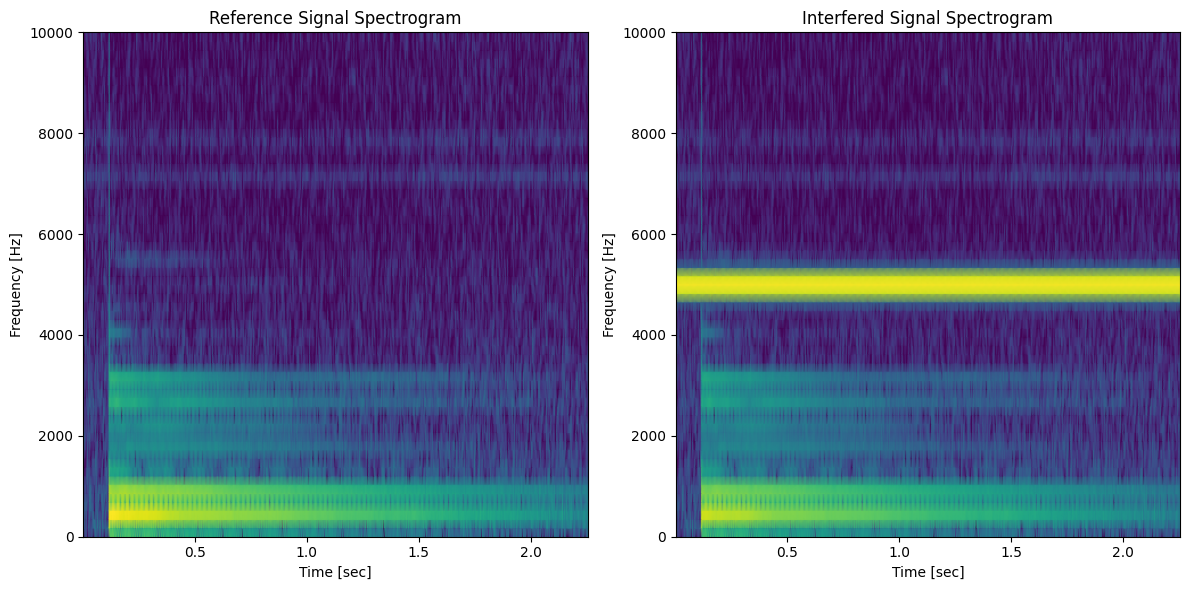

In [118]:
# Write your code here
ff, tt, S_ref = signal.spectrogram(ref, fs=fs, window = 'hann')
ff_interf, tt_interf, S_interf = signal.spectrogram(x_interf, fs=fs, window = 'hann')

plt.figure(figsize = (12,6))

#ref signal
plt.subplot(1,2,1)
plot_spectrogram(ff, tt, S_ref)
plt.ylim([0, 10000])
plt.title('Reference Signal Spectrogram')

#syn signal
plt.subplot(1,2,2)
plot_spectrogram(ff_interf, tt_interf, S_interf)
plt.ylim([0, 10000])
plt.title('Interfered Signal Spectrogram')

plt.tight_layout()
plt.subplot(1,2,1)
plt.show()

3.4. Create a function `remove_interference(x, fs)` that applies a nulling filter devised to remove the interference at 1000 Hz. 

Note: remember that a frequency can be converted to the normalized radian frequncy by: $\omega_n = 2\pi f_n/f_s$

In [119]:
def remove_interference(x, fs):
  """Applies nulling filter to remove an interference at 1000 Hz

  Parameters
  ----------
  x : np.array
      The input signal in the form of a numpy array
  fs : int or float
      Frequency rate in Hz

  Returns
  -------
  y : np.array
      The output of the filter

  """
  # Write your code here
  f_n = 5000
  w_n = 2 * np.pi * f_n / fs
  b0 = 1
  b1 = -2 * np.cos(w_n)
  b2 = 1
  kernel = np.array([b0,b1,b2])
  y = np.convolve(x, kernel, mode='same')
  return y 

3.5 Use the `remove_interference` funcion to clean the corrupted signal,  `x_interf`. Call the output as `x_clean`. Compare the spectrograms of both signals. Explain the result.

In [120]:
x_clean = remove_interference(x_interf, fs)
plot_signals([ref, x_clean], fs, t_start , t_end, name=['input [x] (ref)', 'output [y] (clean)'], mode= 'lines+markers')

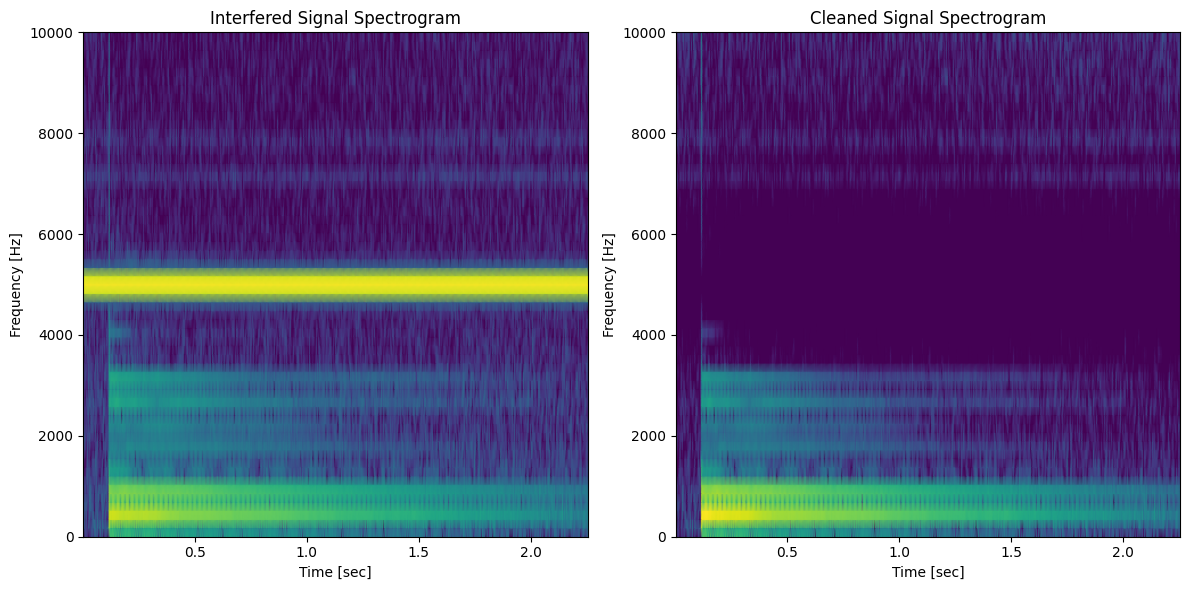

In [121]:
ff_interf, tt_interf, S_interf = signal.spectrogram(x_interf, fs=fs, window = 'hann')
ff_clean, tt_clean, S_clean = signal.spectrogram(x_clean, fs=fs, window = 'hann') # with x_clean

plt.figure(figsize = (12,6))
#ref signal
plt.subplot(1,2,1)
plot_spectrogram(ff_interf, tt_interf, S_interf)
plt.ylim([0, 10000])
plt.title('Interfered Signal Spectrogram')

#syn signal
plt.subplot(1,2,2)
plot_spectrogram(ff_clean, tt_clean, S_clean)
plt.ylim([0, 10000])
plt.title('Cleaned Signal Spectrogram')

plt.tight_layout()
plt.subplot(1,2,1)
plt.show()

In [94]:
ipd.Audio(ref, rate = fs)

In [95]:
ipd.Audio(x_interf, rate=fs)

In [96]:
ipd.Audio(x_clean, rate=fs) # as the ref signal has noise, the clean signal is heard but with noise over it

We can see by cleaning the x_interf, that this line of noise at a chosen frequency (5000 in my case) is removed, and it is only left the signal we want to hear. We can see it reflected on the spectogram, or as I provided the Audio of each signal, we can also see the clear difference by hearing it.

Hence, between the reference signal and the cleaned one, we can spot very few differences, making the noise very similar. 